# Breast Cancer Diagnosis: Building a Linear Classifier from Scratch


**What this notebook covers:** We'll work with the Wisconsin Breast Cancer dataset (569 patient samples, 30 numeric features describing cell nuclei measurements) to predict whether a tumor is **Benign** or **Malignant**.

The goal isn't just to get a working model — it's to understand *how* a linear classifier actually learns. So, we'll implement two classifiers ourselves and compare them.

**The journey:**
| Step | What we do | Why |
|---|---|---|
| **1. Data Analysis** | Explore the data: duplicates, missing values, class balance, distributions, outliers | You can't trust a model built on data you don't understand |
| **2. Preprocessing** | Split, impute, scale, and remove redundant features | Linear models are sensitive to feature scale and multicollinearity |
| **3. Training & Evaluation** | Build a Closed-Form solver and a Gradient Descent solver, then compare them | Two different ways to solve the *same* linear classification problem |

Let's get started.

---


## Setup: Imports & Loading the Data

We start by silencing harmless warnings and importing the libraries we'll need throughout the notebook. We're intentionally importing libraries gradually (rather than all at once) so it's clear *where* each tool first gets used.

In [251]:
import warnings

warnings.filterwarnings('ignore')

In [252]:
import numpy as np
import pandas as pd # Import the pandas library for data manipulation and analysis
import matplotlib.pyplot as plt # Import the matplotlib.pyplot library for creating visualizations
from sklearn.model_selection import train_test_split # Import train_test_split function for splitting data
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling missing values
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate # Import StratifiedKFold for stratified cross-validation and cross_validate for evaluating model performance
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, f1_score # Import ConfusionMatrixDisplay for visualization and confusion_matrix for calculation

from collections import defaultdict




In [253]:
# The zeroth step is loading the data

df = pd.read_csv("/content/dataset.csv", index_col= 0) # Load the CSV file into a pandas DataFrame, using the first column as the index

## Step 1: Data Analysis

Before touching any model, we explore the dataset: its shape, what the columns mean, and whether anything looks off (duplicates, missing values, imbalance, weird distributions, outliers). This step builds the intuition we'll rely on later.

In [254]:
print(df.shape)
 # Display the dimensions (number of rows and columns) of the DataFrame

(569, 32)


In [255]:
# Lets explore the data
df.head(10) # Display the first 10 rows of the DataFrame to get a preview of the data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


The `id` column is just a row identifier with no predictive value, so we drop it before going further.

In [256]:
df = df.drop('id', axis = 1)

In [257]:
df.describe() # Generate descriptive statistics of the DataFrame's numerical columns

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [258]:
df.info() # Print a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 no

### 1.1 Look for Duplicate Rows

Duplicate rows can silently bias a model by over-weighting certain samples, so we check for them first.

In [259]:
duplicate_count = df.duplicated().sum() # Count the total number of duplicate rows in the DataFrame

print(f'The total numbers of duplicate rows found: {duplicate_count}') # Print the count of duplicate rows

The total numbers of duplicate rows found: 0


### 1.2 Look for Missing Values

Missing values need to be handled (dropped or imputed) before a model can use the data — here we just check how widespread the problem is.

In [260]:
missing_values = df.isna().sum()

if missing_values.sum() == 0:
    print("There are no missing values.")
else:
    for col, count in missing_values.items():
        if count > 0:
            percentage_missing = (count / len(df)) * 100
            print(f'{col}: {percentage_missing:.1f}%')

There are no missing values.


### 1.3 Check for Class Imbalance

Our target is `diagnosis`: **B**enign or **M**alignant. If one class dominates, accuracy alone becomes a misleading metric, so it's worth knowing the split upfront.

In [261]:
class_count = df['diagnosis'].value_counts()
print(class_count)
# Count the occurrences of each class in the 'diagnosis' column
percentage = df['diagnosis'].value_counts(normalize=True)*100 # Calculate the percentage of each class in the 'diagnosis' column

print(f'Count, Percentage of patients with Benign Tumors: {class_count[0]}, {percentage[0]:.1f}%') # Print the count and percentage for benign tumors
print(f'Count, Percentage of patients with Malignant Tumors: {class_count[1]}, {percentage[1]:.1f}%') # Print the count and percentage for malignant tumors

diagnosis
B    357
M    212
Name: count, dtype: int64
Count, Percentage of patients with Benign Tumors: 357, 62.7%
Count, Percentage of patients with Malignant Tumors: 212, 37.3%


### 1.4 Univariate Analysis

We look at numeric and categorical columns separately, then visualize the distribution of every numeric feature with histograms.

In [262]:
numeric_cols = df.select_dtypes(include = 'number').columns # Select columns with numeric data types
print(f'Total number of numerical columns present : {len(numeric_cols)}') # Print the list of numeric column names

Total number of numerical columns present : 30


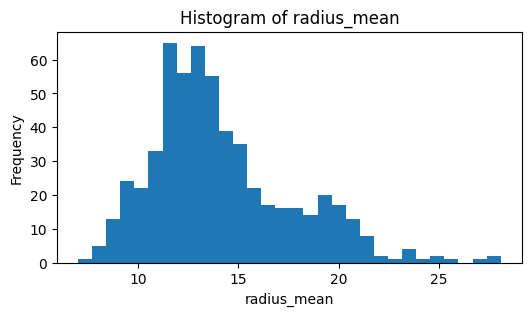

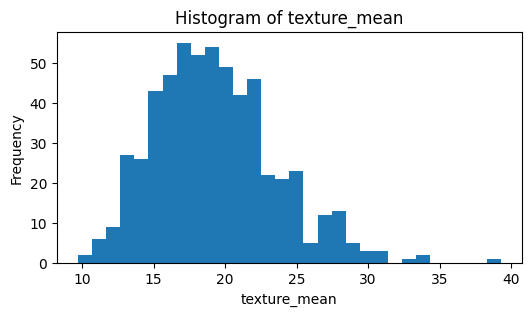

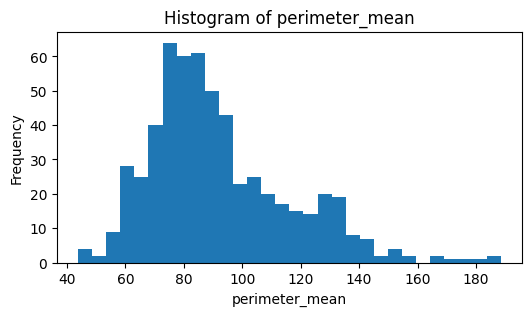

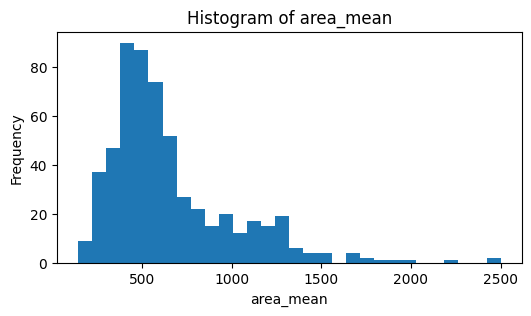

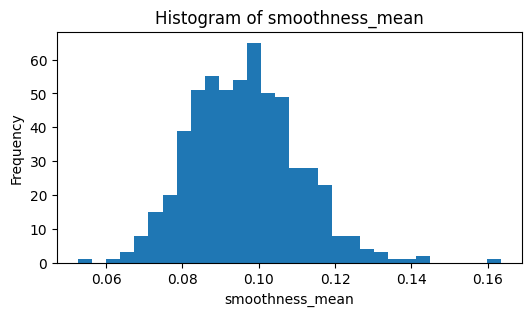

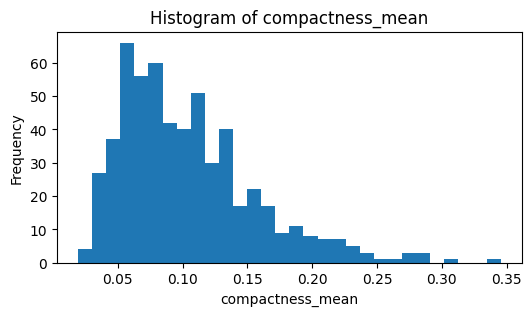

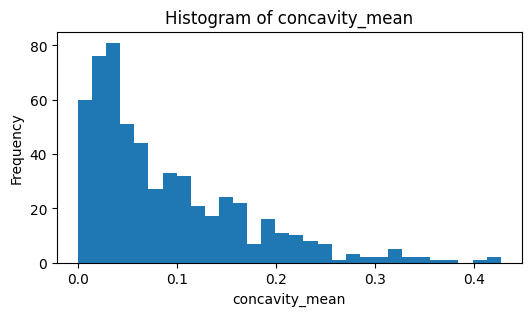

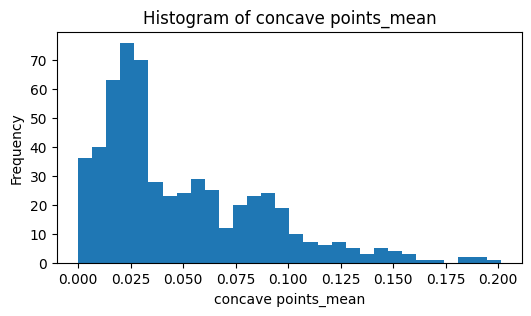

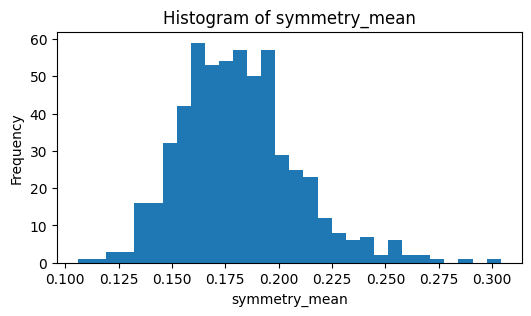

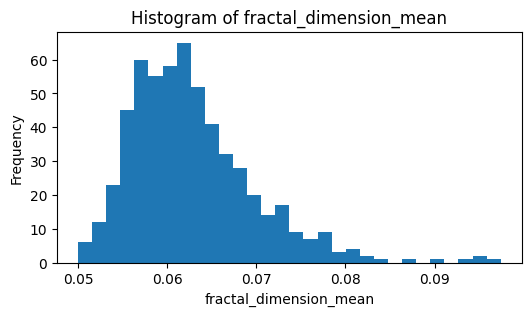

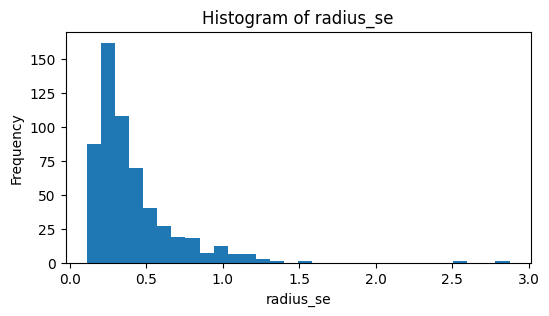

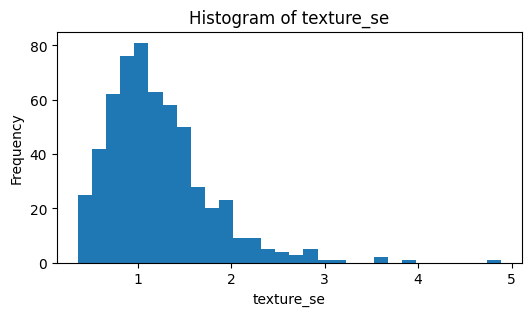

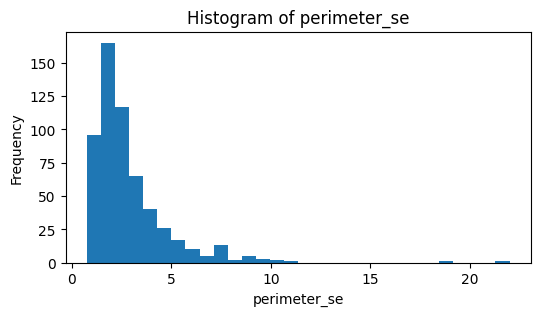

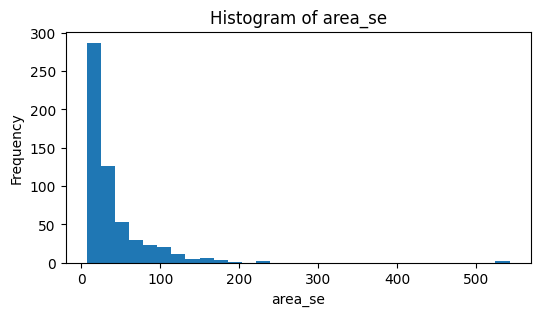

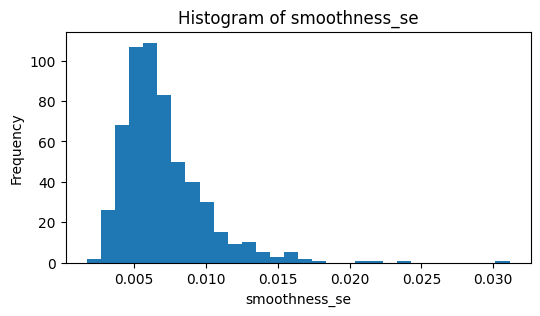

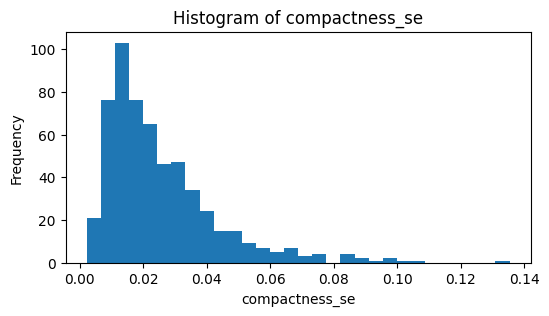

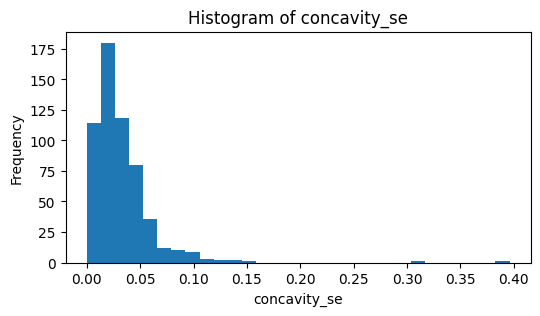

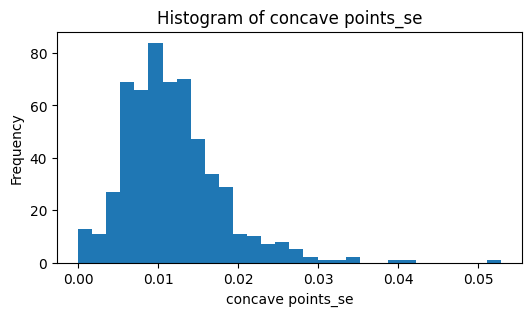

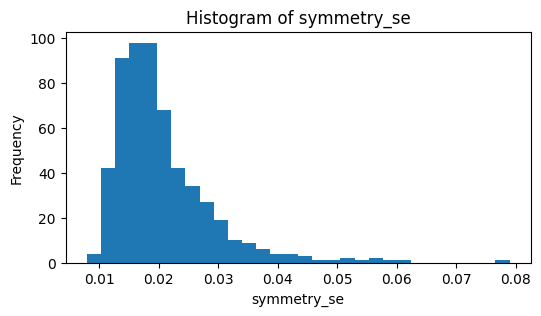

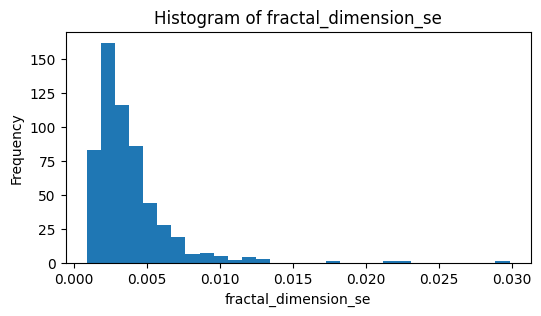

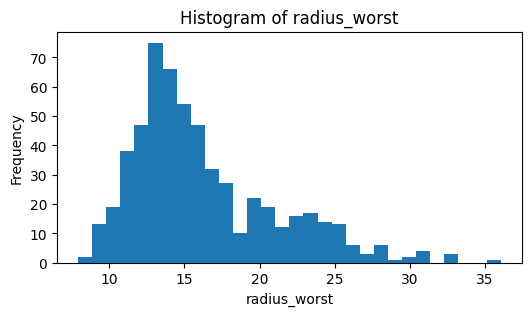

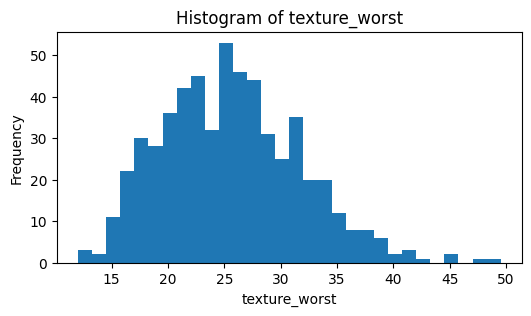

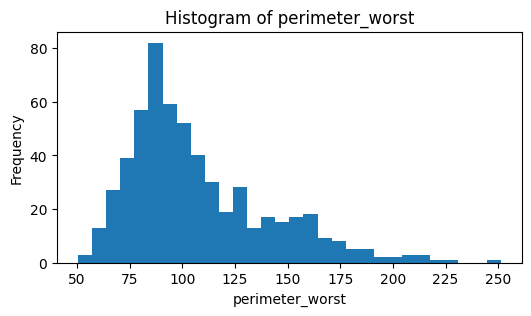

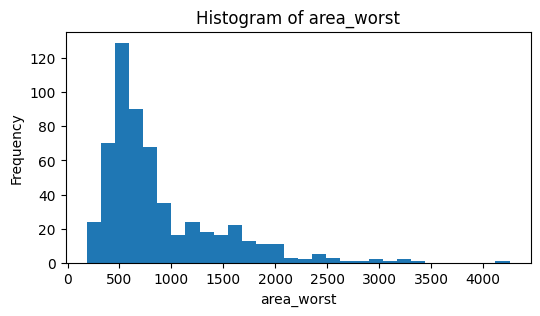

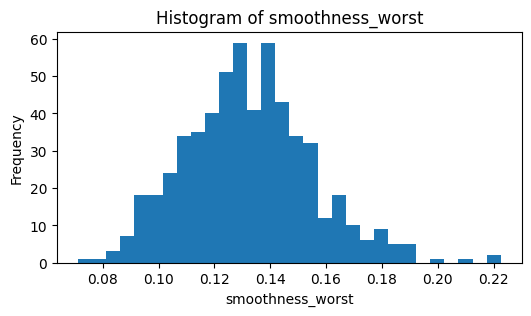

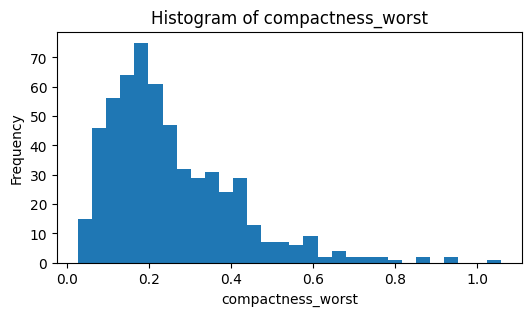

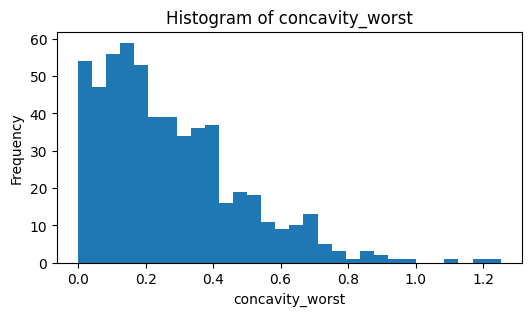

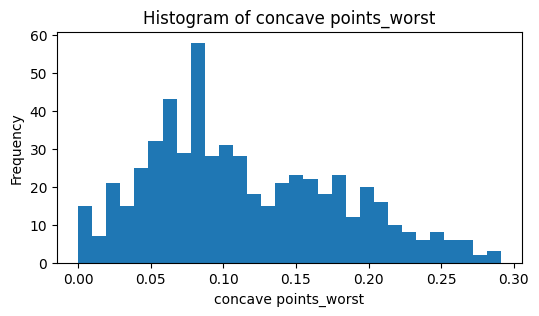

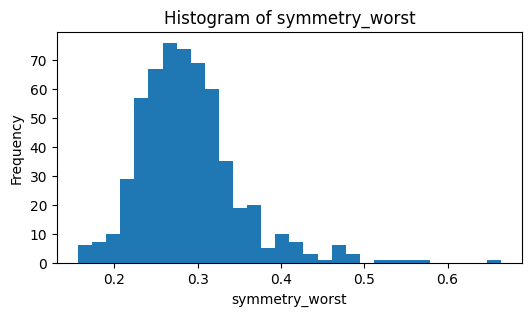

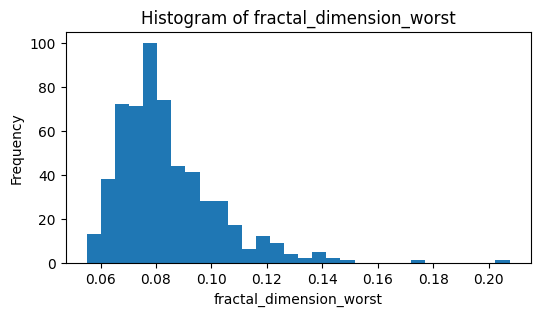

In [263]:
for col in numeric_cols: # Iterate through each numeric column

    plt.figure(figsize=(6, 3)) # Create a new figure for each histogram with a specified size

    plt.hist( # Generate a histogram
        df[col].dropna(), # Use data from the current column, dropping any missing values
        bins=30 # Set the number of bins for the histogram
    )

    plt.title(f"Histogram of {col}") # Set the title of the histogram
    plt.xlabel(col) # Set the x-axis label
    plt.ylabel("Frequency") # Set the y-axis label

    plt.show() # Display the histogram

In [264]:
categorical_cols = df.select_dtypes(include = 'object').columns # Select columns with numeric data types
print(f'Categorical Columns : {list(categorical_cols)}') # Print the list of categorical column names

Categorical Columns : ['diagnosis']


In [265]:
#   Give Prof. 10 minutes to discuss the impact of outliers

### 1.5 Check for Outliers

Using the IQR (Interquartile Range) method, we flag values that fall far outside the typical range for each feature. This doesn't mean we remove them — it just tells us where the data is noisiest.

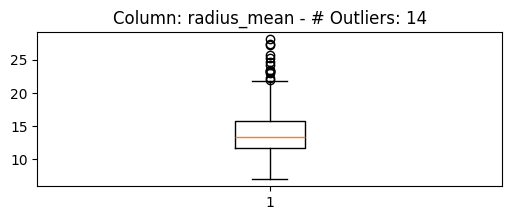

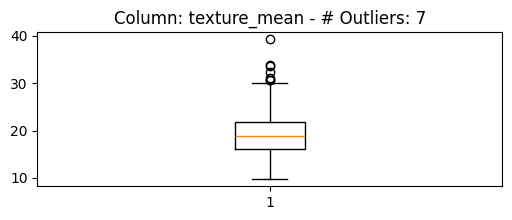

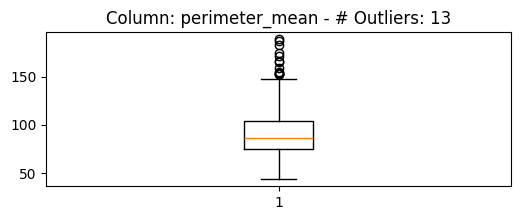

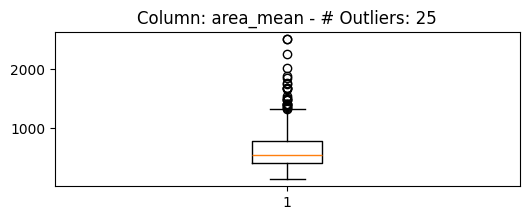

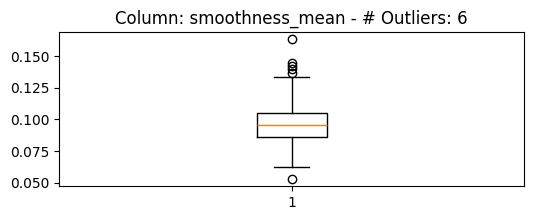

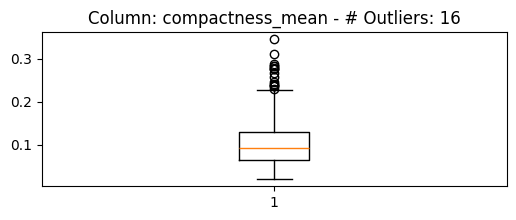

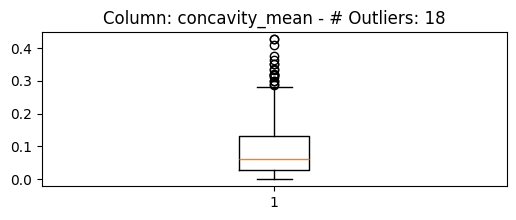

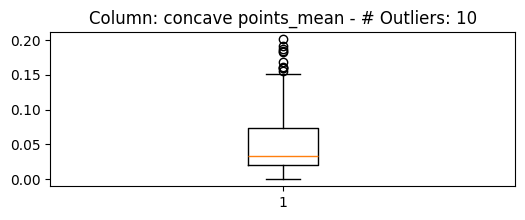

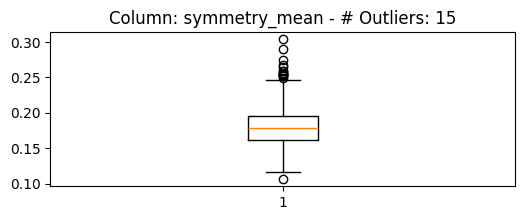

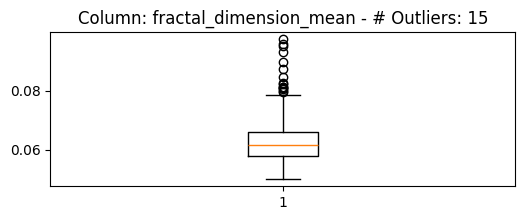

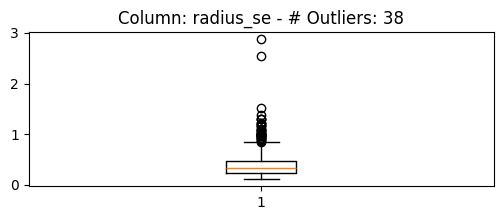

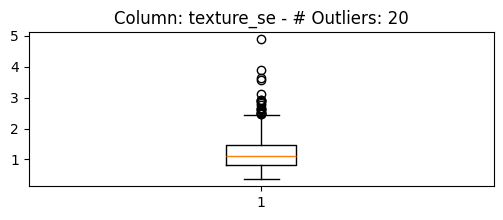

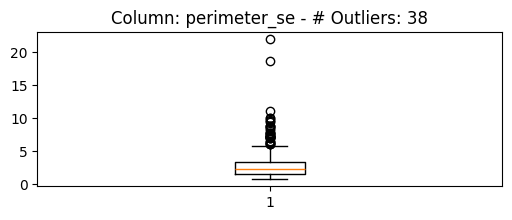

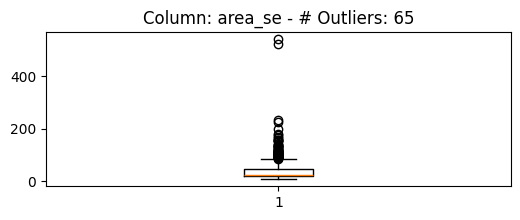

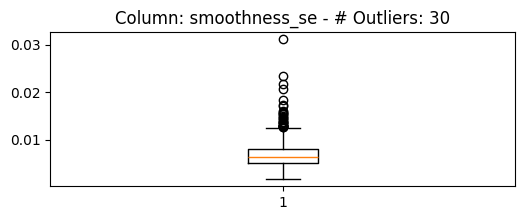

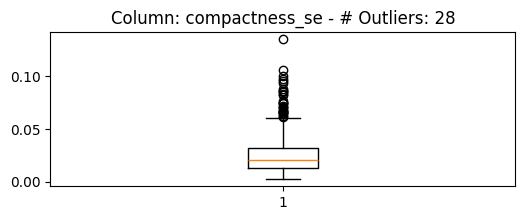

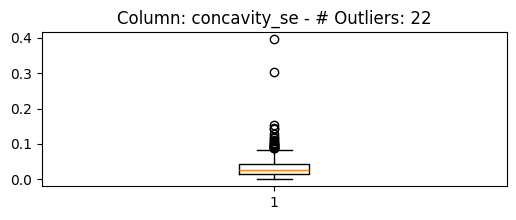

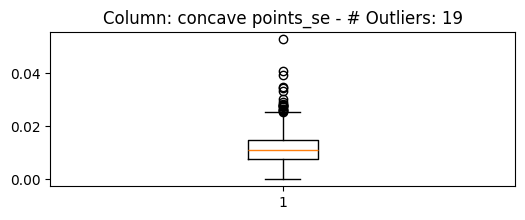

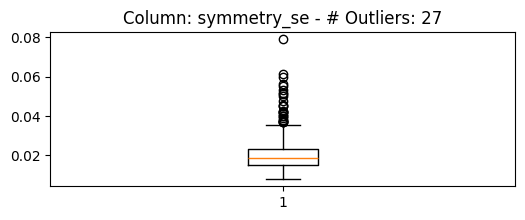

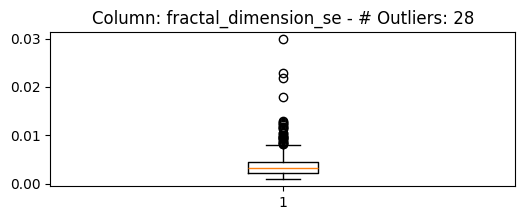

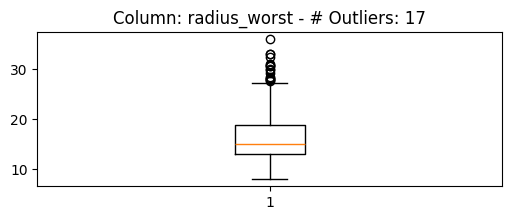

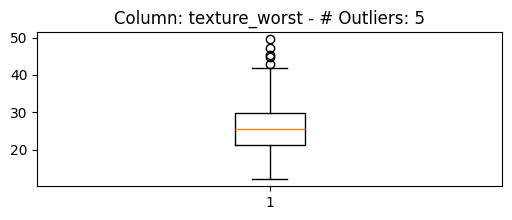

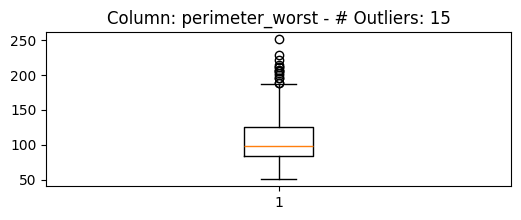

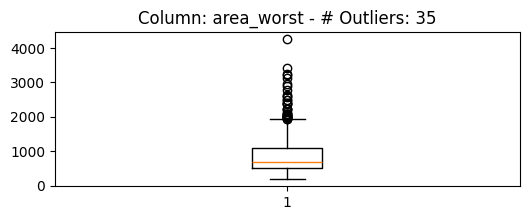

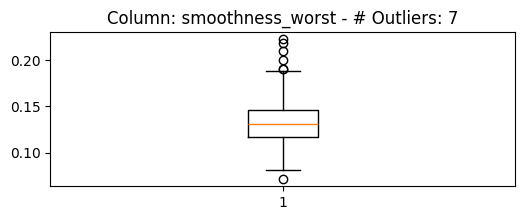

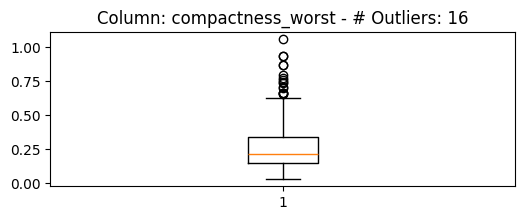

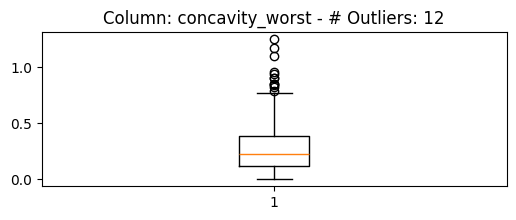

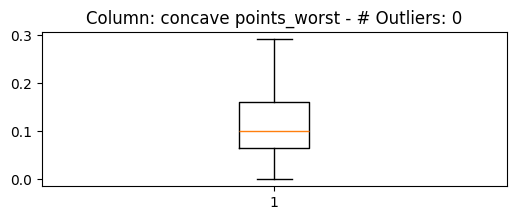

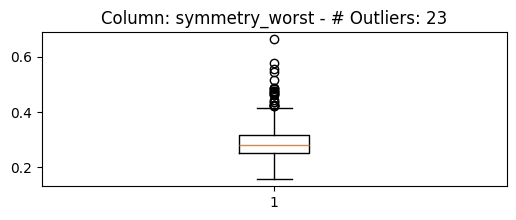

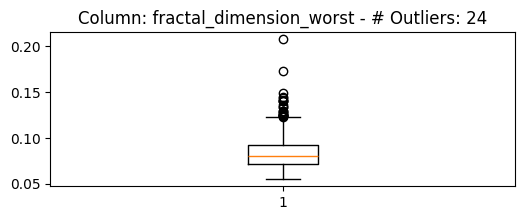

In [266]:
for col in numeric_cols: # Iterate through each numeric column

  Q1 = df[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = df[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (df[col] < lower) | (df[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR

  plt.figure(figsize = (6,2)) # Create a new figure for each box plot
  plt.boxplot(df[col].dropna()) # Generate a box plot for the current column, dropping missing values

  plt.title(f'Column: {col} - # Outliers: {num_outliers}') # Set the title of the box plot including the outlier count (this is the count found BEFORE imputation, i.e. how many were fixed)

  plt.show() # Display the box plot





## Step 2: Preprocessing

Now we prepare the data for modeling. This means splitting it into train/test sets, filling any missing values, scaling features so they're on comparable ranges, and removing redundant (highly correlated) features.

### 2.1 Split Data into Train and Test Sets

We hold out 20% of the data as a test set that the model never sees during training. `stratify=y` ensures both sets keep the same Benign/Malignant ratio as the full dataset.

In [267]:
X = df.drop('diagnosis', axis = 1) # Create feature matrix X by dropping the 'diagnosis' column
y = df['diagnosis']
y = np.where(df['diagnosis'] == 'M', 1, -1) # Create target vector y: 1 for Malignant, -1 for Benign


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y) # Split data into training and test sets (80% train, 20% test)
# 'random_state' ensures reproducibility, 'stratify=y' maintains the same proportion of target classes in both splits

In [268]:
print(f"Total patients: {len(df)}") # Print the total number of patients in the original dataset
print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)") # Print the size and percentage of the training set
print(f"Test set size: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)") # Print the size and percentage of the test set

print(
f"  Class split in training: " # Print header for class distribution in training set
    f"{(y_train==-1).sum()/len(X_train):.1%} Benign, "
    f"{(y_train==1).sum()/len(X_train):.1%} Malignent"
)

print(
    f"  Class split in test:     " # Print header for class distribution in test set
    f"{(y_test==-1).sum()/len(X_test):.1%} Benign, "
    f"{(y_test==1).sum()/len(X_test):.1%} Malignant"
)

print("\nstratify=y ensures both splits have the same % of Benign vs Malignant cases") # Explain the purpose of stratify=y

Total patients: 569
Training set size: 455 (80%)
Test set size: 114 (20%)
  Class split in training: 62.6% Benign, 37.4% Malignent
  Class split in test:     63.2% Benign, 36.8% Malignant

stratify=y ensures both splits have the same % of Benign vs Malignant cases


### 2.2 Removing Outliers

In [269]:
remove_outliers_Flag = False  # Set to True to impute outliers with the column median, False to just visualize/count them as before

for col in numeric_cols: # Iterate through each numeric column

  Q1 = X_train[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = X_train[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (X_train[col] < lower) | (X_train[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR




  if remove_outliers_Flag and num_outliers > 0:
    median_val = X_train.loc[~outlier_mask, col].median() # Median computed from non-outlier values only, so the outliers themselves don't skew the value used to replace them
    X_train.loc[outlier_mask, col] = median_val # Replace each outlier with that column's median

    # apply the SAME train-fit bounds and value to test — no new stats from X_test
    test_outlier_mask = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[test_outlier_mask, col] = median_val


### 2.2 Fixing Missing Values

Even though we confirmed earlier there are no missing values in this dataset, we still set up an imputer here as good practice — in a real pipeline, train and test data should always be processed through the same fitted steps.

In [270]:
numeric_cols = X.select_dtypes(include = 'number').columns # Re-identify numeric columns from X (features)
categorical_cols = X.select_dtypes(include = 'object').columns # Re-identify categorical columns from X (features)

In [271]:
num_imputer = SimpleImputer(strategy='median') # Initialize SimpleImputer to fill missing numerical values with the median

X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols]) # Fit the imputer on training numeric columns and transform them

X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

print(X_train[numeric_cols].isna().sum()) # Verify that there are no more missing values in the numeric training columns

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


### 2.3 Scaling

Our features are measured on very different scales (e.g. `area_mean` is in the hundreds, `smoothness_mean` is near 0.1). `StandardScaler` rescales each feature to have mean 0 and standard deviation 1, which matters a lot for linear models. Note: the scaler is **fit only on training data**, then applied to the test set — this avoids leaking test-set information.

In [272]:
scaler = StandardScaler() # Initialize StandardScaler

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) # Fit the scaler on training numeric columns and transform them

In [273]:
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols]) # Transform the test set's numeric columns using the scaler fitted on the training data

In [274]:
# Give Professor 10  minutes

### 2.4 Visualizing Correlation

With 30 features, some are likely measuring very similar things (e.g. `radius_mean` and `perimeter_mean`). A correlation heatmap helps us spot these relationships visually before we decide what to do about them.

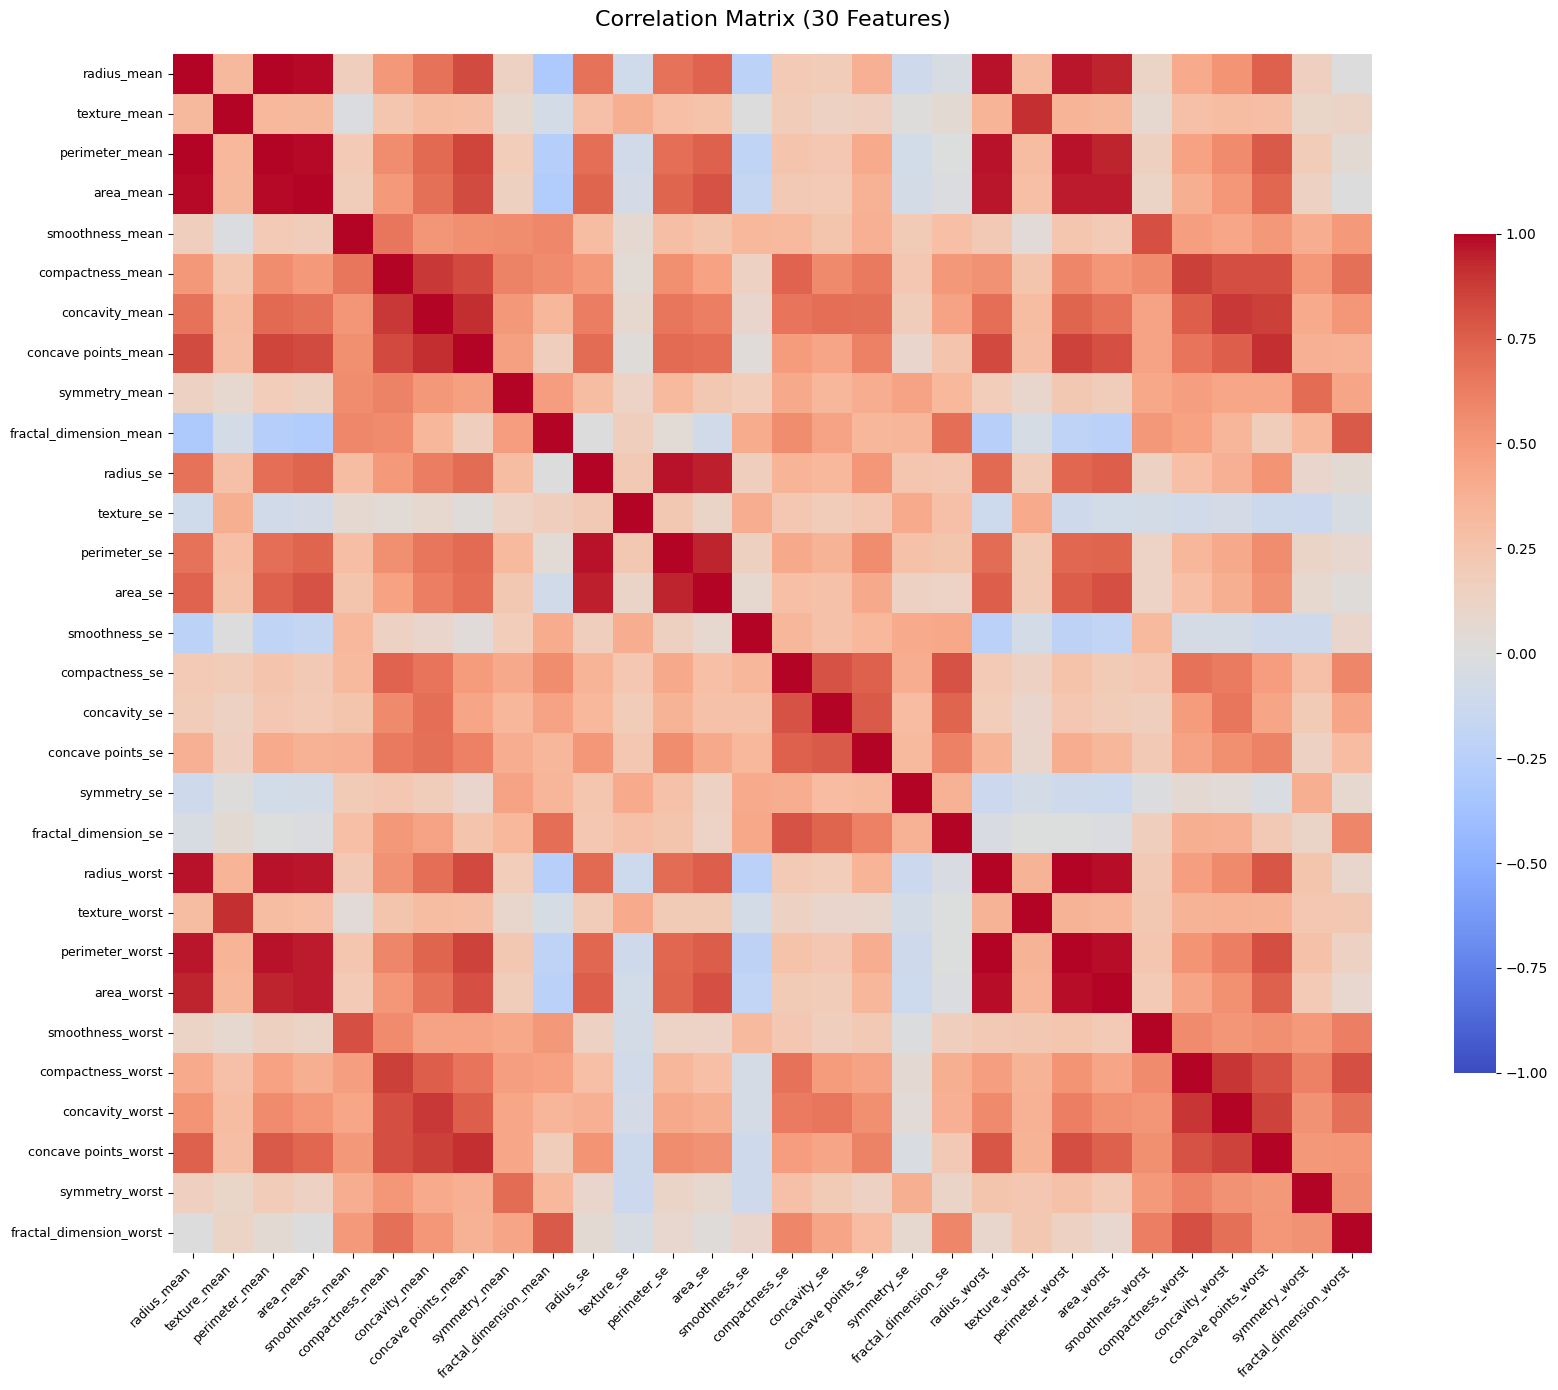

In [275]:
corr_matrix = X.corr()
plt.figure(figsize=(18, 14))


sns.heatmap(
    corr_matrix,
    #mask=mask,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)

plt.title('Correlation Matrix (30 Features)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 2.5 Removing Highly Correlated Features

Highly correlated (redundant) features add noise without adding new information, and can make linear models less stable. Here we drop one feature from any pair with a correlation above 0.9, cutting our feature count.

In [276]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9

to_drop = [
    col for col in upper.columns
    if any(upper[col] > threshold)
]

X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

print(f"Original features: {X_train.shape[1]}")
print(f"Remaining features: {X_train_reduced.shape[1]}")

X_train = X_train_reduced
X_test = X_test_reduced

Original features: 30
Remaining features: 20


## Step 3: Training and Evaluation

With clean, scaled, de-correlated features ready, we now build a linear classifier two different ways:

1. **Closed-Form Solution** — solve for the optimal weights directly using linear algebra (one-shot, exact for this formulation).
2. **Gradient Descent** — start from random weights and iteratively nudge them in the direction that reduces error.

Both aim to solve the *same* problem, just with different mechanics. Comparing them helps build intuition for *why* gradient descent is the approach that scales to more complex models (like neural networks), even though the closed-form solution looks simpler here.

### 3.1 Linear Classifier — Closed-Form Solution

This classifier solves for weights `w` directly by solving a system of linear equations (the normal equations), with no iteration or learning rate involved.

In [277]:
import numpy as np

class ClosedFormLinearClassifier:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X_aug = np.c_[np.ones(X.shape[0]), X] # add one more column having value 1 for all samples

        XtX = X_aug.T @ X_aug
        Xty = X_aug.T @ y

        self.w = np.linalg.solve(XtX, Xty) # np.linalg.solve(A, b) solves for x, when Ax = b
        return self

    def predict(self, X):
        X_aug = np.c_[np.ones(X.shape[0]), X]
        scores = X_aug @ self.w
        return np.where(scores >= 0, 1, -1)

We fit it on the training data and generate predictions on the held-out test set.

In [278]:
model = ClosedFormLinearClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Results — Closed-Form Classifier:**

Accuracy : 95.6%
Precision: 1.000
Recall   : 0.881
F1 Score   : 0.937


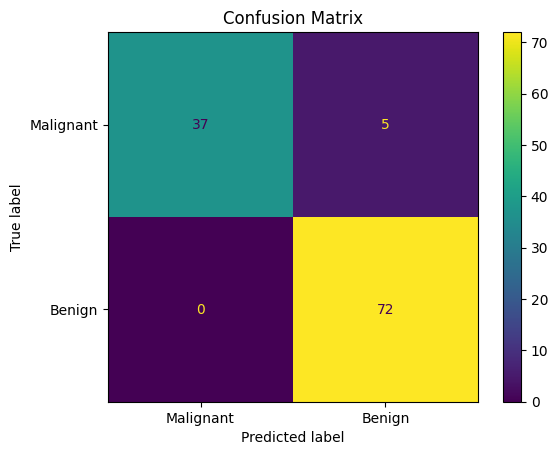

In [279]:
accuracy = np.mean(y_pred == y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy*100:.1f}%')
print(f'Precision: {precision:.3f}')
print(f'Recall   : {recall:.3f}')
print(f'F1 Score   : {f1:.3f}')

cm = confusion_matrix(y_test, y_pred, labels = [1, -1]) # Calculate the confusion matrix
disp = ConfusionMatrixDisplay( # Initialize ConfusionMatrixDisplay with the calculated confusion matrix
    confusion_matrix=cm,
    display_labels = ['Malignant', 'Benign']
)

disp.plot() # Plot the confusion matrix

plt.title("Confusion Matrix") # Set the title of the plot
plt.show() # Display the plot

### 3.2 Linear Classifier — Gradient Descent

This version starts with weights at zero and updates them step by step, in the direction that reduces the Mean Squared Error, controlled by a learning rate (`lr`) and number of iterations (`n_iters`).

In [280]:
class GDLinearClassifier:
    def __init__(self, lr=0.1, n_iters=500):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.loss_history = None

    def fit(self, X, y, X_val=None, y_val=None):
        X_aug = np.c_[np.ones(X.shape[0]), X]

        if X_val is not None:
            X_val_aug = np.c_[np.ones(X_val.shape[0]), X_val]

        n, d = X_aug.shape
        self.w = np.zeros(d)

        self.loss_history = []
        self.val_loss_history = []

        for _ in range(self.n_iters):
            residual = X_aug @ self.w - y

            grad = 2 * (X_aug.T @ residual) / n # take home exercise: The Mean Square Error and Gradient Calculation
            self.w -= self.lr * grad

            train_loss = (residual @ residual) / n
            self.loss_history.append(train_loss)

            if X_val is not None:
                val_residual = X_val_aug @ self.w - y_val
                val_loss = (val_residual @ val_residual) / (2 * len(y_val))
                self.val_loss_history.append(val_loss)


        return self


    def predict(self, X):
        X_aug = np.c_[np.ones(X.shape[0]), X]
        scores = X_aug @ self.w
        return np.where(scores >= 0, 1, -1)

    def get_mse_history(self):
      return self.loss_history, self.val_loss_history

#### Tuning the Learning Rate

The learning rate controls how big each update step is — too small and training is slow, too large and it can overshoot or diverge. We use 5-fold stratified cross-validation to test a few candidate learning rates and track training vs. validation loss for each.

In [281]:
scores = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

learning_rates = [0.115, 0.01, 0.0001]
lr_loss_history = defaultdict(list)
for lr in learning_rates:
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

        X_train_, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_, y_val = y_train[train_idx], y_train[val_idx]

        model = GDLinearClassifier(lr=lr, n_iters=100)
        model.fit(X_train_, y_train_, X_val, y_val)

        y_pred = model.predict(X_val)
        scores.append(np.mean(y_pred == y_val))

        if fold == 0:
          train_history, val_history = model.get_mse_history()
          lr_loss_history[lr] = [train_history, val_history]

**What to look for in the plots below:** a learning rate that's too small will show a loss curve that's still decreasing slowly by the end of training, while one that's too large may show an unstable or diverging curve. We're looking for the rate where both training and validation loss settle down smoothly.

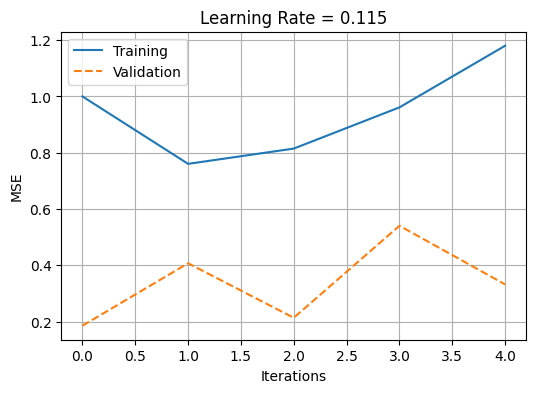

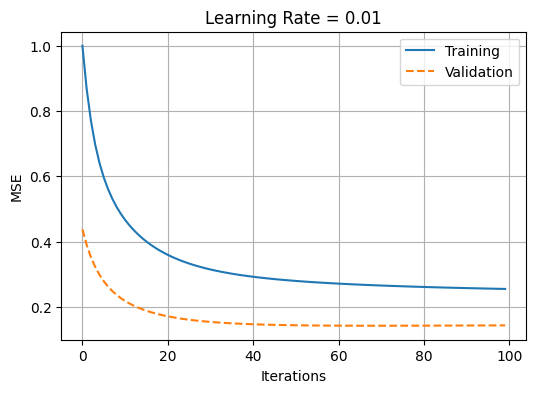

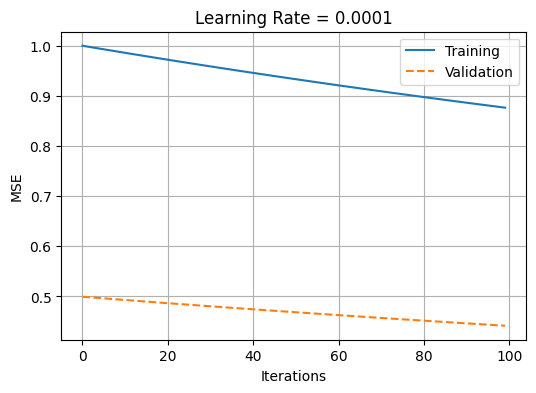

In [282]:
for lr, (train_history, val_history) in lr_loss_history.items():

    plt.figure(figsize=(6,4))




    if lr > 0.1:
      cutoff = 5
      plt.plot(train_history[:cutoff], label="Training")
      plt.plot(val_history[:cutoff], '--', label="Validation")


      plt.ylabel("log10(MSE)")
    else:
      plt.plot(train_history, label="Training")
      plt.plot(val_history, '--', label="Validation")


    plt.title(f"Learning Rate = {lr}")
    plt.xlabel("Iterations")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    plt.show()

Based on the curves above, we pick a learning rate of `0.01` with `200` iterations, train on the full training set, and evaluate on the test set.

In [283]:
model = GDLinearClassifier(lr=0.01, n_iters=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Results — Gradient Descent Classifier:**

Accuracy : 95.6%
Precision: 1.000
Recall   : 0.881
F1 Score : 0.937


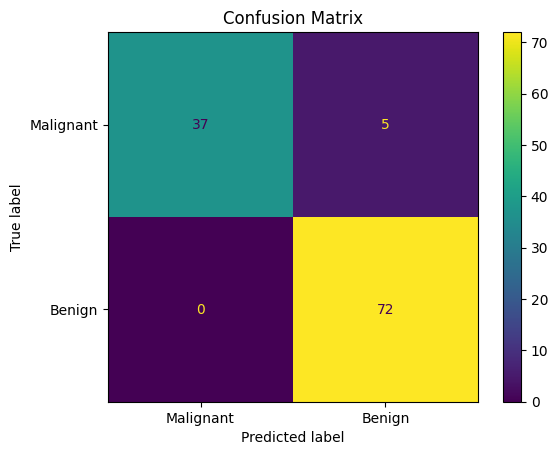

In [284]:

accuracy = np.mean(y_pred == y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy*100:.1f}%')
print(f'Precision: {precision:.3f}')
print(f'Recall   : {recall:.3f}')
print(f'F1 Score : {f1:.3f}')

cm = confusion_matrix(y_test, y_pred, labels = [1, -1]) # Calculate the confusion matrix
disp = ConfusionMatrixDisplay( # Initialize ConfusionMatrixDisplay with the calculated confusion matrix
    confusion_matrix=cm,
    display_labels = ['Malignant', 'Benign']
)

disp.plot() # Plot the confusion matrix

plt.title("Confusion Matrix") # Set the title of the plot
plt.show() # Display the plot

## Summary

Both classifiers tackle the same linear classification problem, with two different solving strategies:


### Before Imputing Outliers
| Classifier | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Closed-Form Solution | 95.6% | 1.00 | 0.88 | 0.94 |
| Gradient Descent (lr=0.1) | 95.6% | 1.00 | 0.88 | 0.94 |


### After Imputing Outliers (Median)
| Classifier | Accuracy | Precision | Recall | F1 Score
|---|---|---|---|---|
| Closed-Form Solution | 98.2% | 1.00 | 0.95 | 0.98 |
| Gradient Descent (lr=0.1) | 98.2% | 1.00 | 0.95 | 0.98 |

**Takeaways for learners:**
- The **closed-form solution** solves the problem exactly in one step, but doing so requires inverting a matrix — this becomes computationally expensive (or infeasible) as the number of features grows very large, or doesn't exist in closed form for more complex models.
- **Gradient descent** trades exactness for scalability: it's slower to converge here, but it's the same core mechanism that trains far more complex models (like deep neural networks) where no closed-form solution exists at all.
- Both models achieved high precision and high recall — very important in a medical diagnosis context where false positives and false negatives carry very different costs.

In later weeks, we'll move beyond this from-scratch implementation to industry-standard libraries like `scikit-learn`, but the intuition built here — what's actually happening inside `model.fit()` — carries forward to every model we build next.




---






## Take-Home Problem 1

### Objective
Is there a way to leverage sckit-learns's `LinearRegression` to solve the same problem? If yes, Fit the training data using Scikit-learn's `LinearRegression` model and compare its performance with the from-scratch implementation of Linear Classifier in the notebook

### Steps

1. Train Scikit-learn's `LinearRegression` model on the same training set.
3. Generate predictions on the test set.
4. Compute the evaluation metrics:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
5. Compare the metrics obtained from both implementations.


## Take-Home Problem 2


Your dataset contains:

- **1,000,000 samples**
- **100 features**

Would you use the **closed-form solution** for Linear Regression or **Gradient Descent**? Justify your answer.

## Take-Home Problem 3


Explain why do we impute outliers **after splitting** into train and test set, when we could have done that **before splitting**?

## Take-Home Problem 4
Which of the following datasets can be classified by a linear classifier and why?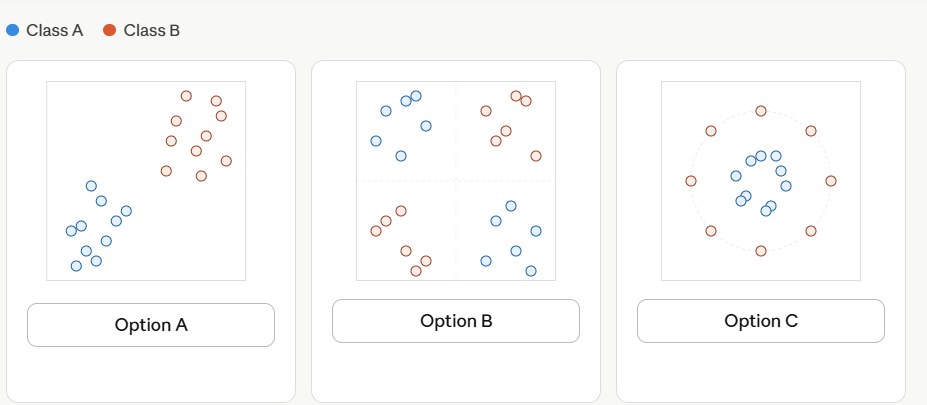


## Take-Home Problem 5


Suppose some numerical features in your dataset are highly skewed. How would you identify the **skewness**, and what techniques would you use to address it before training a machine learning model?